<a href="https://colab.research.google.com/github/yeji79/brain-age-gap-adni/blob/main/notebooks/02_brain_age_bag_mvp_phc_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ADNI PHC 구조 MRI 기반 Brain Age Gap (BAG): MVP 분석

이 노트북은 **ADSP PHC ComBat 보정 FreeSurfer ROI**로 정상 인지군(CN)의 뇌 나이 모델을 학습하고, 보정된 Brain Age Gap(BAG)이 CN·MCI·Dementia 집단에서 다른지 평가합니다.

**연구 질문**: 정상군의 구조 MRI로 학습한 뇌 나이 모델에서, MCI와 Dementia는 같은 실제 나이의 CN보다 더 높은 BAG를 보이는가?

이 분석은 연구·교육 목적의 집단 수준 관찰 분석입니다. 개인 치매 진단, 미래 위험 판정, 인과관계, 개인의 노화 속도를 주장하지 않습니다.

## 전체 흐름

```text
데이터 로드 → index MRI 코호트 구축 → 전처리/EDA → CN-only 모델 학습
→ validation 나이 편향 보정 → 독립 CN test 평가 → 전체 코호트 BAG 계산
→ 진단군 ANCOVA → ROI 중요도와 생물학적 의미 정리
```

왜 이 순서인가요? MRI·진단·인구통계 데이터가 정확히 결합되어야 모델 결과가 신뢰할 수 있고, 학습에 쓰지 않은 CN test가 있어야 성능이 과장되지 않습니다. MCI와 Dementia는 정상 노화 기준을 배우는 데 사용하지 않고, 마지막 BAG 비교에서만 사용합니다.

## 0. 라이브러리와 분석 원칙

Colab에서는 아래 셀을 한 번 실행합니다. `pyarrow`는 사용하지 않으며, 모든 중간 결과는 CSV로 저장합니다.

- `RID`: ADNI 참가자 식별자. 같은 RID가 train/test 양쪽에 들어가면 데이터 누수가 생깁니다.
- `ComBat`: MRI 장비·센터 차이를 줄인 사전 조화 ROI입니다.
- `N_JOBS=1`: 환경별 병렬 처리 권한 오류를 피하기 위한 안전 설정입니다.

In [1]:
!pip -q install pandas numpy scikit-learn matplotlib seaborn statsmodels

from pathlib import Path
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, GroupKFold, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

warnings.filterwarnings('ignore', category=FutureWarning)
SEED = 20260819
MAX_ALIGNMENT_DAYS = 180
MIN_FEATURE_COMPLETENESS = 0.70
N_JOBS = 1
random.seed(SEED); np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')

## 1. 경로와 데이터 로드

Google Drive에 `brain-age-gap-adni` 프로젝트 폴더 전체를 업로드한 뒤 `PROJECT_ROOT`만 자신의 경로로 바꾸세요. ADNI 원본 자료는 데이터 사용 계약에 따라 Git에 올리지 않습니다.

이 MVP에서 쓰는 핵심 파일은 다음 네 가지입니다.

- `ADSP_PHC_T1_FS`: ComBat 보정 구조 MRI ROI와 PHC 나이·성별·진단
- `PTDEMOG`: 교육연수 보강
- `DXSUM`: PHC 진단 결측 시 가까운 임상 진단 보강
- `ADSP_PHC_T1_FS_DATADIC`: PHC ROI의 해부학적 이름과 단위

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

PROJECT_ROOT = Path('/content/drive/MyDrive/brain-age-gap-adni')  # 본인 Google Drive 경로로 수정
DATA_DIR = PROJECT_ROOT / 'data'
ADNI_ROOT = DATA_DIR / 'adni_all'
assert ADNI_ROOT.exists(), f'ADNI 원본 폴더를 찾지 못했습니다: {ADNI_ROOT}'

PROCESSED_DIR = DATA_DIR / 'processed'
FIG_DIR = PROJECT_ROOT / 'results' / 'figures'
TABLE_DIR = PROJECT_ROOT / 'results' / 'tables'
for folder in [PROCESSED_DIR, FIG_DIR, TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

def one_file(pattern, required=True):
    matches = sorted(ADNI_ROOT.glob(pattern))
    if required:
        assert matches, f'파일을 찾지 못했습니다: {pattern}'
    return matches[-1] if matches else None

paths = {
    # Date must follow T1_FS_ immediately; this excludes the separate *_DATADIC file.
    'phc_fs': one_file('ADSP_PHC/ADSP_PHC_T1_FS_22Jan*.csv'),
    'phc_dict': one_file('ADSP_PHC/ADSP_PHC_T1_FS_DATADIC_*.csv'),
    'demo': one_file('Subject_Characteristics/PTDEMOG_*.csv'),
    'dx': one_file('Assessments/DXSUM_*.csv'),
}

phc = pd.read_csv(paths['phc_fs'], low_memory=False)
phc_dict = pd.read_csv(paths['phc_dict'], low_memory=False)
demo = pd.read_csv(paths['demo'], low_memory=False)
dx = pd.read_csv(paths['dx'], low_memory=False)

print('PHC T1 FreeSurfer:', phc.shape)
print('PHC data dictionary:', phc_dict.shape)
print('PTDEMOG:', demo.shape)
print('DXSUM:', dx.shape)

PHC T1 FreeSurfer: (10260, 212)
PHC data dictionary: (211, 10)
PTDEMOG: (6222, 84)
DXSUM: (15992, 41)


## 2. 데이터 정렬과 index MRI 코호트

ADNI는 한 사람이 여러 방문과 여러 MRI를 가질 수 있습니다. 반복 MRI가 학습과 test에 동시에 들어가면 모델이 같은 사람을 기억할 수 있으므로, MVP에서는 **RID별 가장 이른 유효 T1 MRI 한 건**만 선택합니다. 이를 `index MRI`라고 부릅니다.

PHC의 `PHC_Age_T1`은 MRI 촬영 시점의 나이이므로 출생연도로 다시 계산한 나이보다 우선 사용합니다. 진단은 PHC 값을 우선 쓰고, 결측일 때만 MRI 날짜와 ±180일 이내 DXSUM 진단으로 보강합니다.

In [4]:
def standardize_rid(df):
    out = df.copy()
    out['RID'] = pd.to_numeric(out['RID'], errors='coerce').astype('Int64')
    return out

def to_datetime_col(df, col):
    out = df.copy()
    out[col] = pd.to_datetime(out[col], errors='coerce')
    return out

def diagnosis_label(value):
    value = pd.to_numeric(value, errors='coerce')
    return {1: 'CN', 2: 'MCI', 3: 'Dementia'}.get(value, np.nan)

def nearest_by_rid(left, right, left_date, right_date, fields, max_days=MAX_ALIGNMENT_DAYS):
    """For each left row, attach fields from the nearest dated right row with the same RID."""
    base = left.copy().reset_index(names='_left_row')
    right_keep = right[['RID', right_date] + fields].dropna(subset=['RID', right_date]).copy()
    candidates = base[['_left_row', 'RID', left_date]].merge(right_keep, on='RID', how='left')
    candidates['_days'] = (candidates[right_date] - candidates[left_date]).abs().dt.days
    candidates = candidates[candidates['_days'].le(max_days)].copy()
    if candidates.empty:
        for field in fields:
            base[field] = np.nan
        return base.drop(columns='_left_row')
    nearest = (candidates.sort_values(['_left_row', '_days', right_date])
                         .drop_duplicates('_left_row', keep='first')
                         [['_left_row'] + fields])
    return base.merge(nearest, on='_left_row', how='left').drop(columns='_left_row')

# PHC MRI: date, age, sex, diagnosis are already harmonized in one table.
phc = standardize_rid(to_datetime_col(phc, 'PHC_SCANDATE'))
phc['AGE'] = pd.to_numeric(phc['PHC_Age_T1'], errors='coerce')
phc['diagnosis_phc'] = phc['PHC_Diagnosis'].map(diagnosis_label)
phc['sex'] = phc['PHC_Sex'].map({1: 'Male', 2: 'Female'}).fillna(phc['PHC_Sex'].astype('string'))

index_mri = (phc.dropna(subset=['RID', 'PHC_SCANDATE', 'AGE'])
                .sort_values(['RID', 'PHC_SCANDATE'])
                .drop_duplicates('RID', keep='first')
                .rename(columns={'PHC_SCANDATE': 'MRI_DATE'})
                .copy())

# Education is a stable demographic covariate: one RID-level record is sufficient.
demo = standardize_rid(to_datetime_col(demo, 'VISDATE'))
demo['education'] = pd.to_numeric(demo['PTEDUCAT'], errors='coerce')
demo_unique = (demo.dropna(subset=['RID'])
                 .sort_values(['RID', 'VISDATE'])
                 .drop_duplicates('RID', keep='last')[['RID', 'education']])
cohort = index_mri.merge(demo_unique, on='RID', how='left', validate='one_to_one')

# Use DXSUM only as a fallback for missing PHC diagnosis.
dx = standardize_rid(to_datetime_col(dx, 'EXAMDATE'))
dx['diagnosis_dx'] = dx['DIAGNOSIS'].map(diagnosis_label)
cohort = nearest_by_rid(cohort, dx, 'MRI_DATE', 'EXAMDATE', ['diagnosis_dx'])
cohort['diagnosis'] = cohort['diagnosis_phc'].fillna(cohort['diagnosis_dx'])
cohort['eTIV'] = pd.to_numeric(cohort['EstimatedTotalIntraCranialVol_combat'], errors='coerce')

# Pre-specified eligible age range; retain only the three primary clinical groups.
cohort = cohort[cohort['AGE'].between(55, 95) & cohort['diagnosis'].isin(['CN', 'MCI', 'Dementia'])].copy()
cohort['diagnosis'] = pd.Categorical(cohort['diagnosis'], ['CN', 'MCI', 'Dementia'])

assert cohort['RID'].is_unique, 'index MRI cohort must contain one row per RID'
assert cohort['AGE'].notna().all(), 'AGE should be complete after eligibility filtering'
print(f'Index MRI records: {len(index_mri):,}')
print(f'Analysis cohort: {len(cohort):,} participants')
display(cohort['diagnosis'].value_counts().rename_axis('diagnosis').to_frame('n'))

Index MRI records: 2,504
Analysis cohort: 2,484 participants


,n
diagnosis,
MCI,1143
CN,938
Dementia,403


## 3. ROI 정의와 전처리 계획

PHC 파일의 `_combat` 열은 ComBat 조화가 적용된 MRI 측정값입니다. 이 노트북에서는 해부학적 ROI를 모델에 넣되, eTIV 자체와 이미 eTIV 비율인 전역 지표는 모델 입력에서 제외합니다.

부피 ROI를 다시 단순 ICV 비율로 바꾸지 않는 이유는, 제공된 값이 이미 ComBat 조화된 측정값이기 때문입니다. eTIV는 진단군 ANCOVA의 공변량으로 사용합니다.

결측률 기준은 **CN train에서만** 계산합니다. test·MCI·Dementia의 정보를 ROI 선택에 쓰지 않기 위해서입니다.

In [5]:
combat_columns = [c for c in phc.columns if c.endswith('_combat')]
exclude_from_model = {
    'EstimatedTotalIntraCranialVol_combat',
    'BrainSegVol.to.eTIV_combat',
    'MaskVol.to.eTIV_combat',
}
roi_candidates = [c for c in combat_columns if c not in exclude_from_model and c in cohort.columns]

# Dictionary is used only for readable anatomical labels; feature choice stays code-based and reproducible.
feature_labels = (phc_dict[['FLDNAME', 'TEXT']].dropna().drop_duplicates('FLDNAME')
                  .set_index('FLDNAME')['TEXT'].to_dict())

assert len(roi_candidates) > 100, 'Unexpectedly few PHC ComBat ROI candidates'
print(f'ComBat candidates: {len(combat_columns)}')
print(f'ROI candidates after eTIV exclusions: {len(roi_candidates)}')
print(f'Anatomical labels available: {sum(c in feature_labels for c in roi_candidates)}')

ComBat candidates: 192
ROI candidates after eTIV exclusions: 189
Anatomical labels available: 189


## 4. EDA: 분석 전 반드시 확인할 것

EDA(Exploratory Data Analysis)는 모델을 잘 보이게 만드는 단계가 아니라, 데이터가 연구 질문에 맞는지 확인하는 단계입니다.

여기서는 다음을 확인합니다.

- 진단군마다 표본 수와 나이 분포가 크게 다른지
- 성별, 교육연수, eTIV의 결측치가 어느 정도인지
- MRI ROI 결측률이 특정 변수에 집중되는지

진단군 간 나이 분포가 다르면 BAG도 나이 영향을 받을 수 있으므로, 이후 ANCOVA에서 나이를 보정합니다.

,n,age_mean,age_sd,education_mean,etiv_mean
diagnosis,,,,,
CN,938,72.18,6.66,16.47,1497562.77
MCI,1143,72.84,7.55,15.70,1533813.88
Dementia,403,74.74,7.97,14.56,1517330.73


sex,Female,Male
diagnosis,,
CN,536,402
MCI,490,653
Dementia,184,219


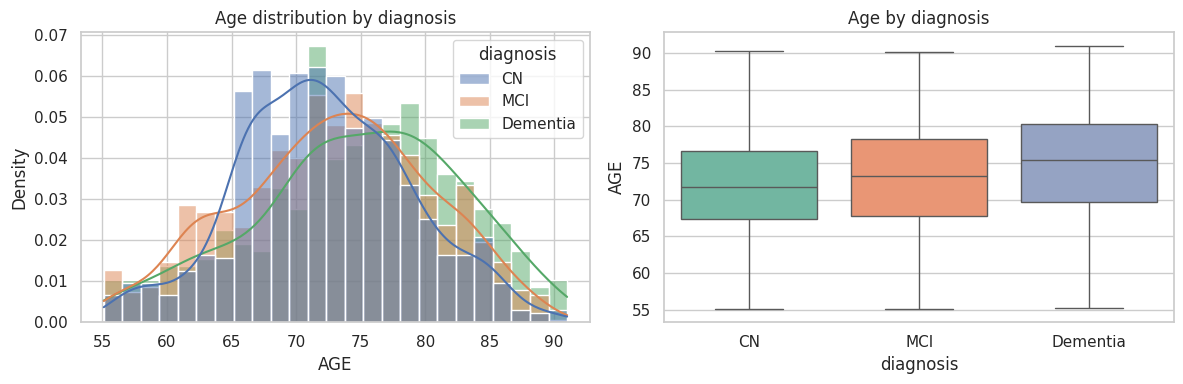

,missing_fraction
education,0.019726
AGE,0.000000
sex,0.000000
eTIV,0.000000
X3rd.Ventricle_combat,0.000000
X4th.Ventricle_combat,0.000000
Brain.Stem_combat,0.000000
BrainSegVol_combat,0.000000
BrainSegVolNotVentSurf_combat,0.000000
CC_Anterior_combat,0.000000


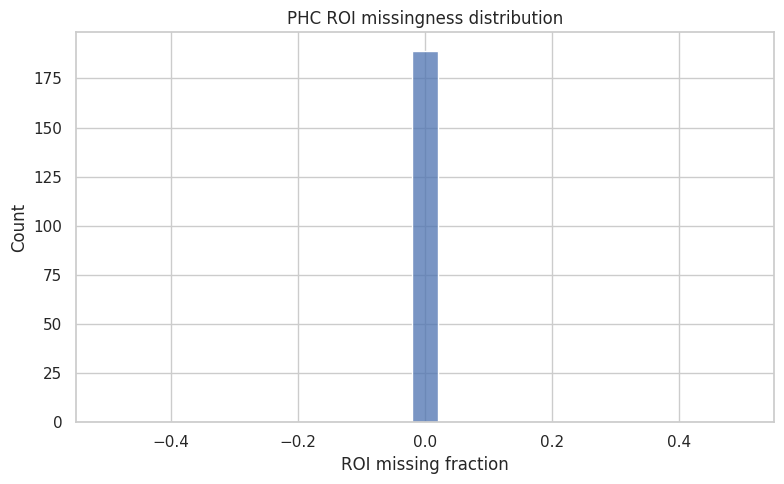

In [6]:
table1 = (cohort.groupby('diagnosis', observed=False)
          .agg(n=('RID', 'size'),
               age_mean=('AGE', 'mean'), age_sd=('AGE', 'std'),
               education_mean=('education', 'mean'),
               etiv_mean=('eTIV', 'mean'))
          .round(2))
sex_counts = pd.crosstab(cohort['diagnosis'], cohort['sex'], dropna=False)
display(table1)
display(sex_counts)
table1.to_csv(TABLE_DIR / 'table1_demographics.csv')
sex_counts.to_csv(TABLE_DIR / 'table1_sex_counts.csv')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=cohort, x='AGE', hue='diagnosis', stat='density', common_norm=False, kde=True, ax=axes[0])
axes[0].set_title('Age distribution by diagnosis')
sns.boxplot(data=cohort, x='diagnosis', y='AGE', ax=axes[1], palette='Set2')
axes[1].set_title('Age by diagnosis')
plt.tight_layout(); plt.savefig(FIG_DIR / 'eda_age_by_diagnosis.png', dpi=300); plt.show()

audit_columns = ['AGE', 'sex', 'education', 'eTIV'] + roi_candidates
missingness = cohort[audit_columns].isna().mean().sort_values(ascending=False)
display(missingness.head(20).rename('missing_fraction').to_frame())
missingness.rename('missing_fraction').to_csv(TABLE_DIR / 'missingness_all_candidates.csv')

plt.figure(figsize=(8, 5))
sns.histplot(missingness[roi_candidates], bins=25)
plt.xlabel('ROI missing fraction'); plt.title('PHC ROI missingness distribution')
plt.tight_layout(); plt.savefig(FIG_DIR / 'eda_roi_missingness.png', dpi=300); plt.show()

## 5. CN-only split과 train 기반 ROI 선택

뇌 나이 모델의 정상 기준은 CN에서만 만듭니다. 같은 RID가 여러 분할에 섞이지 않도록 `GroupShuffleSplit`에 RID를 전달합니다. 현재 index MRI는 RID당 한 행이지만, 이 원칙을 코드에 명시하면 이후 종단 분석으로 확장할 때도 안전합니다.

ROI 결측률 필터도 train CN에서만 계산합니다. 이 원칙은 test와 환자군의 분포가 학습 설계에 미리 영향을 주는 것을 막습니다.

In [7]:
cn = cohort[cohort['diagnosis'].eq('CN')].copy()
assert cn['RID'].nunique() >= 30, 'CN sample is too small for the planned split'

split_1 = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=SEED)
train_idx, hold_idx = next(split_1.split(cn, groups=cn['RID']))
cn_train, cn_hold = cn.iloc[train_idx].copy(), cn.iloc[hold_idx].copy()

split_2 = GroupShuffleSplit(n_splits=1, train_size=0.50, random_state=SEED + 1)
val_idx, test_idx = next(split_2.split(cn_hold, groups=cn_hold['RID']))
cn_val, cn_test = cn_hold.iloc[val_idx].copy(), cn_hold.iloc[test_idx].copy()

for name, frame in {'train': cn_train, 'validation': cn_val, 'test': cn_test}.items():
    print(f'{name:11s}: {len(frame):4,} RID | age {frame.AGE.mean():.1f} ± {frame.AGE.std():.1f}')

train_missing = cn_train[roi_candidates].isna().mean()
roi_features = train_missing[train_missing <= (1 - MIN_FEATURE_COMPLETENESS)].index.tolist()
assert len(roi_features) > 100, 'Too few ROI features after train-only completeness filter'

feature_manifest = pd.DataFrame({
    'feature_code': roi_features,
    'anatomical_label': [feature_labels.get(c, c) for c in roi_features],
    'train_missing_fraction': train_missing[roi_features].values,
})
feature_manifest.to_csv(TABLE_DIR / 'roi_feature_manifest.csv', index=False)
print(f'Final MRI ROI features: {len(roi_features)}')
display(feature_manifest.head())

train      :  656 RID | age 72.1 ± 6.6
validation :  141 RID | age 72.9 ± 6.9
test       :  141 RID | age 72.0 ± 6.8
Final MRI ROI features: 189


,feature_code,anatomical_label,train_missing_fraction
0,X3rd.Ventricle_combat,3rd ventricle volume harmonized with combat,0.0
1,X4th.Ventricle_combat,4th ventricle volume harmonized with combat,0.0
2,Brain.Stem_combat,Brainstem volume harmonized with combat,0.0
3,BrainSegVol_combat,Segmented brain volume harmonized with combat,0.0
4,BrainSegVolNotVentSurf_combat,Surface size of the segmented brain volume exc...,0.0


## 6. 모델 설계와 학습

모델은 MRI ROI와 성별로 실제 나이를 예측합니다.

- `DummyRegressor`: 평균 나이만 예측하는 최소 기준선
- `Ridge`: 상관된 ROI를 안정적으로 다루는 사전 지정 주 모델
- `Extra Trees`: 비선형 관계가 도움이 되는지 확인하는 비교 모델

중앙값 대치·표준화·one-hot 인코딩은 모두 `Pipeline` 안에 들어 있습니다. 따라서 각 CV fold의 train 부분에서만 학습되어 누수를 막습니다. 결과가 조금 더 좋아도, Ridge와 비선형 모델의 성능 차이가 작다면 해석 가능성이 높은 Ridge를 주 모델로 유지합니다.

In [8]:
model_features = roi_features + ['sex']

preprocessor = ColumnTransformer([
    ('roi', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
    ]), roi_features),
    ('sex', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]), ['sex']),
])

model_specs = {
    'Dummy mean age': (
        Pipeline([('prep', preprocessor), ('model', DummyRegressor())]), {}
    ),
    'Ridge': (
        Pipeline([('prep', preprocessor), ('model', Ridge())]),
        {'model__alpha': [0.1, 1.0, 10.0, 100.0]}
    ),
    'Extra Trees': (
        Pipeline([('prep', preprocessor), ('model', ExtraTreesRegressor(random_state=SEED, n_jobs=N_JOBS))]),
        {'model__n_estimators': [300], 'model__min_samples_leaf': [1, 3]}
    ),
}

cv = GroupKFold(n_splits=5)
searches, cv_rows = {}, []
for name, (pipeline, params) in model_specs.items():
    search = GridSearchCV(
        estimator=pipeline, param_grid=params, scoring='neg_mean_absolute_error',
        cv=cv, n_jobs=N_JOBS, refit=True
    )
    search.fit(cn_train[model_features], cn_train['AGE'], groups=cn_train['RID'])
    searches[name] = search
    cv_rows.append({
        'model': name,
        'cv_mae': -search.best_score_,
        'best_parameters': str(search.best_params_),
    })

cv_results = pd.DataFrame(cv_rows).sort_values('cv_mae')
display(cv_results.round(3))
cv_results.to_csv(TABLE_DIR / 'model_selection_cv.csv', index=False)

# Pre-specified primary model: Ridge. Extra Trees remains a transparent comparator.
age_model = searches['Ridge'].best_estimator_
print('Primary Brain Age model: Ridge')

,model,cv_mae,best_parameters
2,Extra Trees,3.903,"{'model__min_samples_leaf': 3, 'model__n_estim..."
1,Ridge,3.913,{'model__alpha': 100.0}
0,Dummy mean age,5.279,{}


Primary Brain Age model: Ridge


## 7. Validation 기반 나이 편향 보정

뇌 나이 모델은 젊은 사람은 다소 늙게, 고령자는 다소 젊게 예측하는 경향이 있습니다. 이 경향을 보정하지 않으면 BAG가 실제 나이와 연결되어 질병 효과처럼 보일 수 있습니다.

validation CN에서만 아래 관계를 적합하고 계수를 고정합니다.

```text
raw predicted age = α + β × chronological age
corrected predicted age = (raw predicted age − α) / β
BAG = corrected predicted age − chronological age
```

test와 MCI·Dementia는 이 보정식을 새로 학습하는 데 사용하지 않습니다.

In [9]:
val_raw_prediction = age_model.predict(cn_val[model_features])
bias_model = LinearRegression().fit(cn_val[['AGE']], val_raw_prediction)
alpha = float(bias_model.intercept_)
beta = float(bias_model.coef_[0])
assert beta > 0.05, f'Unexpected bias slope: {beta:.3f}'

bias_parameters = pd.DataFrame([{'alpha': alpha, 'beta': beta, 'validation_n': len(cn_val)}])
bias_parameters.to_csv(TABLE_DIR / 'bag_bias_correction_parameters.csv', index=False)
print(f'Frozen bias correction: raw_predicted_age = {alpha:.3f} + {beta:.3f} × actual_age')

def score_bag(frame):
    out = frame.copy()
    out['predicted_age_raw'] = age_model.predict(out[model_features])
    out['predicted_age_corrected'] = (out['predicted_age_raw'] - alpha) / beta
    out['BAG'] = out['predicted_age_corrected'] - out['AGE']
    return out

Frozen bias correction: raw_predicted_age = 35.313 + 0.513 × actual_age


## 8. 독립 CN test 평가

이 셀은 한 번도 모델 학습·ROI 선택·편향 보정에 쓰지 않은 CN test를 평가합니다.

- MAE: 평균 예측 오차(년)
- RMSE: 큰 오차에 더 민감한 지표
- R²: 실제 나이 차이를 설명하는 정도
- BAG–Age correlation: 보정 후 BAG가 실제 나이와 남아 있는 관계
- Dummy 대비 개선: MRI 입력이 평균 나이 예측보다 유용한지

test 결과를 본 뒤 모델·ROI·분할을 다시 바꾸면 test는 더 이상 독립 검증이 아닙니다.

,model,MAE,RMSE,R2,BAG_age_r,MAE_improvement_vs_dummy
0,Ridge (raw),3.943,4.914,0.469,-0.737,1.450
1,Ridge (bias-corrected),5.198,6.536,0.060,-0.102,0.195
2,Dummy mean age,5.393,6.741,-0.000,NaN,0.000


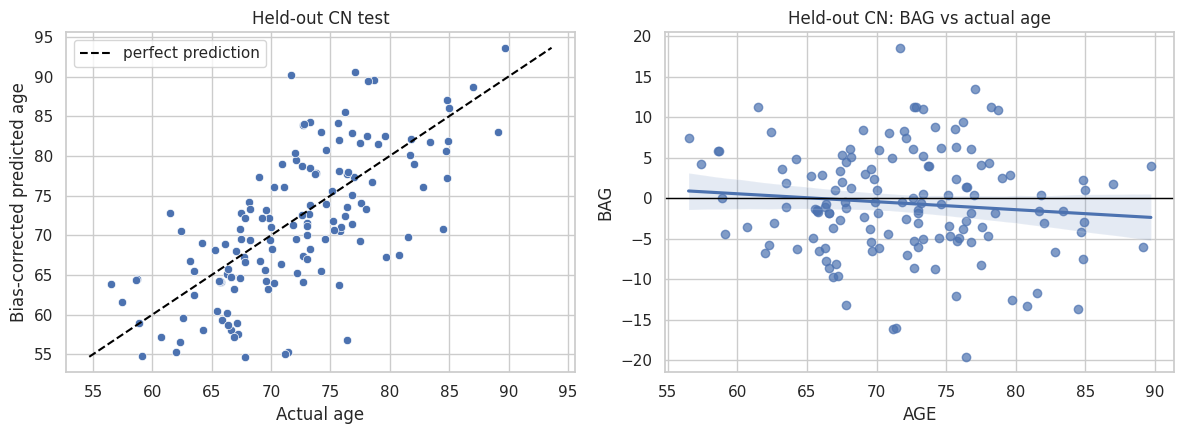

In [10]:
cn_test_scored = score_bag(cn_test)
dummy_prediction = searches['Dummy mean age'].best_estimator_.predict(cn_test[model_features])

test_performance = pd.DataFrame([
    {
        'model': 'Ridge (raw)',
        'MAE': mean_absolute_error(cn_test['AGE'], cn_test_scored['predicted_age_raw']),
        'RMSE': mean_squared_error(cn_test['AGE'], cn_test_scored['predicted_age_raw']) ** 0.5,
        'R2': r2_score(cn_test['AGE'], cn_test_scored['predicted_age_raw']),
        'BAG_age_r': (cn_test_scored['predicted_age_raw'] - cn_test_scored['AGE']).corr(cn_test_scored['AGE']),
    },
    {
        'model': 'Ridge (bias-corrected)',
        'MAE': mean_absolute_error(cn_test['AGE'], cn_test_scored['predicted_age_corrected']),
        'RMSE': mean_squared_error(cn_test['AGE'], cn_test_scored['predicted_age_corrected']) ** 0.5,
        'R2': r2_score(cn_test['AGE'], cn_test_scored['predicted_age_corrected']),
        'BAG_age_r': cn_test_scored['BAG'].corr(cn_test_scored['AGE']),
    },
    {
        'model': 'Dummy mean age',
        'MAE': mean_absolute_error(cn_test['AGE'], dummy_prediction),
        'RMSE': mean_squared_error(cn_test['AGE'], dummy_prediction) ** 0.5,
        'R2': r2_score(cn_test['AGE'], dummy_prediction),
        'BAG_age_r': np.nan,
    },
])
test_performance['MAE_improvement_vs_dummy'] = test_performance.loc[2, 'MAE'] - test_performance['MAE']
display(test_performance.round(3))
test_performance.to_csv(TABLE_DIR / 'model_performance_heldout_cn_test.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.scatterplot(data=cn_test_scored, x='AGE', y='predicted_age_corrected', ax=axes[0])
lims = [min(cn_test_scored['AGE'].min(), cn_test_scored['predicted_age_corrected'].min()),
        max(cn_test_scored['AGE'].max(), cn_test_scored['predicted_age_corrected'].max())]
axes[0].plot(lims, lims, '--', color='black', label='perfect prediction')
axes[0].set(xlabel='Actual age', ylabel='Bias-corrected predicted age', title='Held-out CN test')
axes[0].legend()
sns.regplot(data=cn_test_scored, x='AGE', y='BAG', ax=axes[1], scatter_kws={'alpha': 0.7})
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title('Held-out CN: BAG vs actual age')
plt.tight_layout(); plt.savefig(FIG_DIR / 'heldout_cn_test_evaluation.png', dpi=300); plt.show()

## 9. 주 결과: 진단군 BAG 비교

동결된 Ridge 모델과 동결된 bias correction을 전체 코호트에 적용합니다. 이후 ANCOVA로 다음을 평가합니다.

```text
BAG ~ diagnosis + age + sex + education + eTIV
```

이는 단순히 진단군 평균을 비교하는 것이 아니라, 나이·성별·교육·두개강 용적 차이를 고려한 뒤에도 진단군의 BAG가 다른지 평가하는 방법입니다. 결과는 효과 방향, 평균 차이, 신뢰구간과 함께 해석해야 하며 p값만으로 결론 내리지 않습니다.

,n,mean,sd,median
diagnosis,,,,
CN,938,-0.411,6.286,-0.692
MCI,1143,4.937,8.652,4.528
Dementia,403,12.014,9.600,11.964


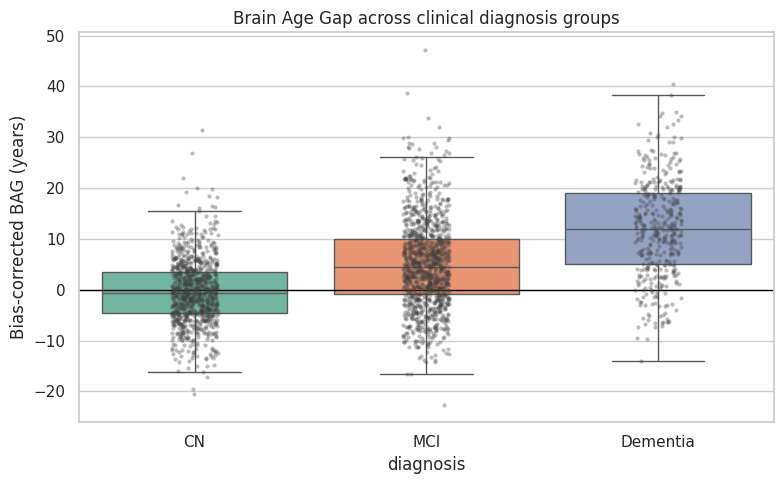

,sum_sq,df,F,PR(>F)
C(diagnosis),38105.954013,2.0,304.992286,6.808094e-119
C(sex),417.291410,1.0,6.679831,9.808850e-03
AGE,2153.154597,1.0,34.466821,4.928542e-09
education,739.056463,1.0,11.830514,5.925120e-04
eTIV,423.183214,1.0,6.774144,9.305052e-03
Residual,151678.026723,2428.0,NaN,NaN


,term,estimate,std_error_HC3,p_value,ci_low,ci_high
0,Intercept,7.4081,2.5552,0.0038,2.3975,12.4187
1,C(diagnosis)[T.MCI],5.0630,0.3408,0.0000,4.3947,5.7313
2,C(diagnosis)[T.Dementia],12.3433,0.5289,0.0000,11.3061,13.3804
3,C(sex)[T.Male],1.0372,0.4013,0.0098,0.2503,1.8241
4,AGE,-0.1431,0.0244,0.0000,-0.1910,-0.0953
5,education,-0.1635,0.0475,0.0006,-0.2568,-0.0703
6,eTIV,0.0000,0.0000,0.0093,0.0000,0.0000


Primary ANCOVA sample: 2,435


In [11]:
scored = score_bag(cohort)
scored['diagnosis'] = pd.Categorical(scored['diagnosis'], ['CN', 'MCI', 'Dementia'])
scored.to_csv(PROCESSED_DIR / 'phc_index_mri_scored_bag.csv', index=False)

bag_summary = (scored.groupby('diagnosis', observed=False)['BAG']
               .agg(n='count', mean='mean', sd='std', median='median')
               .round(3))
display(bag_summary)
bag_summary.to_csv(TABLE_DIR / 'bag_summary_by_diagnosis.csv')

plt.figure(figsize=(8, 5))
sns.boxplot(data=scored, x='diagnosis', y='BAG', palette='Set2', showfliers=False)
sns.stripplot(data=scored, x='diagnosis', y='BAG', color='0.25', alpha=0.35, size=3)
plt.axhline(0, color='black', lw=1)
plt.ylabel('Bias-corrected BAG (years)')
plt.title('Brain Age Gap across clinical diagnosis groups')
plt.tight_layout(); plt.savefig(FIG_DIR / 'bag_by_diagnosis.png', dpi=300); plt.show()

primary_df = scored.dropna(subset=['BAG', 'AGE', 'sex', 'education', 'eTIV', 'diagnosis']).copy()
primary_fit = smf.ols('BAG ~ C(diagnosis) + AGE + C(sex) + education + eTIV', data=primary_df).fit()
primary_ancova = anova_lm(primary_fit, typ=2, robust='hc3')
display(primary_ancova)
primary_ancova.to_csv(TABLE_DIR / 'ancova_diagnosis_hc3.csv')

# Robust coefficient table: useful for direction and confidence intervals.
robust_fit = primary_fit.get_robustcov_results(cov_type='HC3')
coef_table = pd.DataFrame({
    'term': robust_fit.model.exog_names,
    'estimate': robust_fit.params,
    'std_error_HC3': robust_fit.bse,
    'p_value': robust_fit.pvalues,
    'ci_low': robust_fit.conf_int()[:, 0],
    'ci_high': robust_fit.conf_int()[:, 1],
})
display(coef_table.round(4))
coef_table.to_csv(TABLE_DIR / 'diagnosis_model_coefficients_hc3.csv', index=False)
print(f'Primary ANCOVA sample: {len(primary_df):,}')

## 10. 생물학적 의미: ROI 중요도

Permutation importance는 held-out CN test에서 한 ROI의 값을 무작위로 섞었을 때 MAE가 얼마나 나빠지는지 계산합니다. MAE 증가가 큰 ROI일수록 뇌 나이 예측에 유용했던 특징입니다.

이 결과는 **예측 기여도**입니다. 특정 ROI가 중요하다는 사실만으로 그 부위가 알츠하이머병의 원인이라는 결론을 내릴 수는 없습니다. 결과를 해마·내후각피질·측두엽·뇌실 등 알려진 노화 관련 구조와 연결해 조심스럽게 설명합니다.

,feature_code,mae_increase_when_permuted,importance_sd,anatomical_label
2,Brain.Stem_combat,0.224919,0.089253,Brainstem volume harmonized with combat
188,WM.hypointensities_combat,0.204280,0.063848,White matter hypointensities harmonized with c...
0,X3rd.Ventricle_combat,0.163895,0.073704,3rd ventricle volume harmonized with combat
94,lh_transversetemporal_volume_combat,0.108682,0.031983,Left transverse temporal pole grey matter volu...
160,rh_superiortemporal_thickness_combat,0.071680,0.049422,Right superior temporal gyri thickness harmoni...
87,lh_superiortemporal_thickness_combat,0.061486,0.040889,Left superior temporal gyri thickness harmoniz...
57,lh_middletemporal_thickness_combat,0.056151,0.048922,Left middle temporal gyri thickness harmonized...
84,lh_superiorfrontal_volume_combat,0.052722,0.034103,Left superior frontal gyri grey matter volume ...
14,Left.Amygdala_combat,0.052667,0.024000,Left amygdala volume harmonized with combat
41,lh_inferiorparietal_volume_combat,0.051747,0.024989,Left inferior parietal gyri grey matter volume...


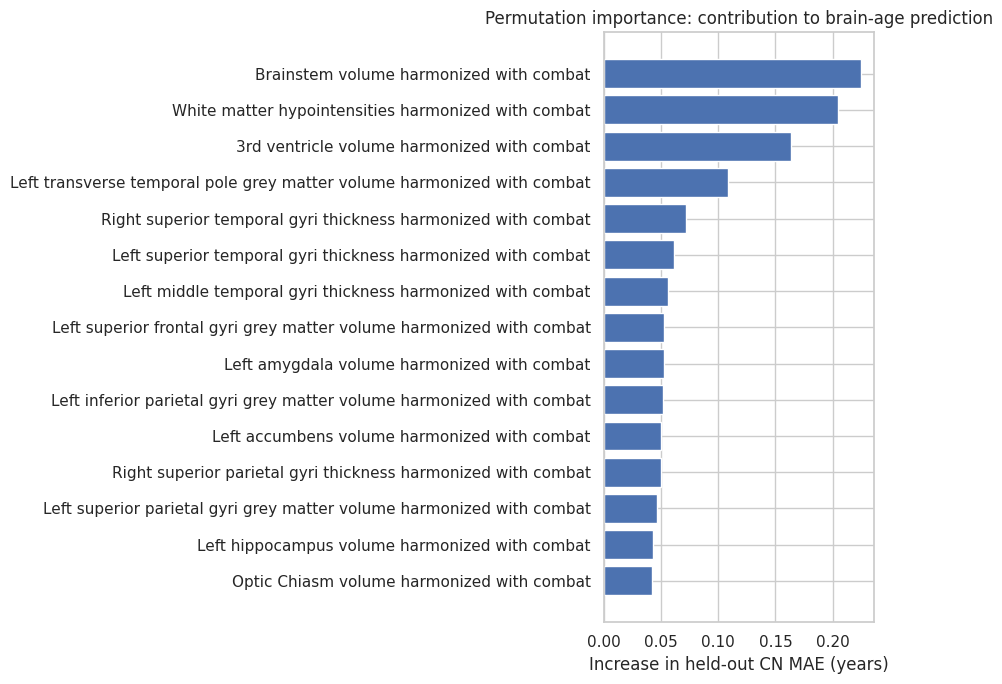

In [12]:
perm = permutation_importance(
    age_model, cn_test[model_features], cn_test['AGE'],
    scoring='neg_mean_absolute_error', n_repeats=20, random_state=SEED, n_jobs=N_JOBS
)
importance = pd.DataFrame({
    'feature_code': model_features,
    'mae_increase_when_permuted': perm.importances_mean,
    'importance_sd': perm.importances_std,
})
importance['anatomical_label'] = importance['feature_code'].map(feature_labels).fillna(importance['feature_code'])
importance = importance.sort_values('mae_increase_when_permuted', ascending=False)
display(importance.head(15))
importance.to_csv(TABLE_DIR / 'permutation_importance_heldout_cn_test.csv', index=False)

top = importance.head(15).sort_values('mae_increase_when_permuted')
plt.figure(figsize=(9, 7))
plt.barh(top['anatomical_label'], top['mae_increase_when_permuted'])
plt.xlabel('Increase in held-out CN MAE (years)')
plt.title('Permutation importance: contribution to brain-age prediction')
plt.tight_layout(); plt.savefig(FIG_DIR / 'permutation_importance_top15.png', dpi=300); plt.show()

## 11. 결과

정상 인지군(CN)의 구조 MRI ROI로 뇌 나이 모델을 학습한 결과, Ridge 모델은 독립 CN 테스트 세트에서 실제 나이를 평균 3.94년 오차(MAE), R²=0.469로 예측했다. 이는 평균 나이만 예측하는 기준 모델보다 MAE가 약 1.45년 낮은 성능이다. 나이 편향을 보정한 Brain Age Gap(BAG)을 이용해 임상군을 비교한 결과, MCI와 Dementia는 CN보다 유의하게 높은 BAG를 보였다. 특히 75세 기준으로 공변량(성별, 교육연수, eTIV)을 보정한 BAG는 MCI에서 CN보다 4.63년, Dementia에서 11.68년 높았다(p<0.001). 다만 진단군 간 BAG 차이는 나이에 따라 유의하게 달라졌으며, 고령으로 갈수록 그 차이가 감소하는 양상이 나타났다.

| 항목 | 결과 |
|---|---:|
| CN 뇌 나이 예측 성능 | MAE 3.94년, RMSE 4.91년, R² 0.469 |
| 기준 모델 대비 | MAE 약 1.45년 개선 |
| 75세 MCI − CN 조정 BAG | +4.63년 |
| 75세 Dementia − CN 조정 BAG | +11.68년 |
| 진단군 효과 | p = 6.30×10⁻¹²⁵ |
| 진단 × 나이 상호작용 | p = 3.28×10⁻¹⁶ |

* 해석
1. MCI·Dementia의 MRI가 같은 연령의 CN보다 더 고령의 정상 뇌 구조와 유사했다. 
2. 개인 진단·치매 위험·질병 진행 속도를 의미하는 결과로는 해석하지 않는다.
3. 나이 예측에 중요했던 ROI에는 뇌간, 백질 고신호 병변, 제3뇌실, 측두엽·해마·편도체 등이 포함됐다.

### 다음 확장 단계

MVP의 모든 표·그림·해석이 완성된 뒤 

- Amyloid PET를 MRI와 ±180일 이내로 연결해 병리 부차 분석
- CN train 기반 normative ROI Z-score로 해부학적 aging burden 분석
- ROI 집합·eTIV 처리·모델을 바꾼 민감도 분석
- `src/` 함수화, README 정리, 결과 자동 저장

원본 ADNI 데이터와 참가자 수준 결과는 데이터 사용 계약에 따라 공개 저장소에 올리지 않습니다.